# Step-by-step NicheMap analysis for GEO/GSM-style Xenium transcript-table data

This tutorial follows the same NicheMap workflow as the standard Xenium tutorial, but the input slice uses a GEO/GSM-style transcript-table format instead of a standard Xenium `outs` folder.

Example input folder:

```text
F:\spatial_data_lung\IPF_2\GSM8505449
```

This folder contains files such as `*_transcripts.csv.gz`, `*_node_meta.csv.gz`, `*_embeddings.npy.gz`, and registered HE images. It may not contain the standard `cell_feature_matrix` and `cells.zarr` files. NicheMap now detects this format automatically and builds an AnnData object from the transcript table.

In [12]:
import os
import sys

# Use the local source tree because this version has not been uploaded to PyPI yet.
local_nichemap_path = os.path.abspath(r"C:\Users\heyi\Desktop\NicheMap")
if local_nichemap_path not in sys.path:
    sys.path.insert(0, local_nichemap_path)

import matplotlib.pyplot as plt
import nichemap
import numpy as np
import pandas as pd
import scanpy as sc

print("Using nichemap from:", nichemap.__file__)


Using nichemap from: C:\Users\heyi\Desktop\NicheMap\nichemap\__init__.py


In [13]:
# -----------------------------------------------------------------------------
# 1. Define input paths and analysis parameters
# -----------------------------------------------------------------------------

# GEO/GSM-style Xenium transcript-table folder.
base_dir = r"F:\spatial_data_lung\IPF_2\GSM8505449"

# Annotation is optional for this dataset. Keep it as None if no annotation map is available.
# If a path is provided but the file is missing, NicheMap will print a message and continue.
anno_file = None

# Gene signature file used by the downstream NicheMap workflow.
gene_list = r"F:\spatial_data_lung\marker_genes\ECM-gene.csv"

score_id = "ECM_score"
bins = 300
peak_intensity = 2.0
exp_intensity = 2.0

out_dir = rf"F:\spatial_data_lung\Xenium_Result_data\GSM8505449_result\{score_id}"
os.makedirs(out_dir, exist_ok=True)

print("base_dir:", base_dir)
print("anno_file:", anno_file)
print("gene_list:", gene_list)
print("out_dir:", out_dir)


base_dir: F:\spatial_data_lung\IPF_2\GSM8505449
anno_file: None
gene_list: F:\spatial_data_lung\marker_genes\ECM-gene.csv
out_dir: F:\spatial_data_lung\Xenium_Result_data\GSM8505449_result\ECM_score


## 2. Load Xenium data

`load_xenium_data` can read both standard Xenium folders and GEO/GSM-style transcript-table folders.

For this dataset, NicheMap will detect `*_transcripts.csv.gz`, aggregate transcript counts by `cell_id` and `feature_name`, compute `x_centroid` and `y_centroid`, and store spatial coordinates in `adata.obsm["spatial"]`.

In [14]:
# -----------------------------------------------------------------------------
# 2. Load Xenium data
# -----------------------------------------------------------------------------
adata = nichemap.preprocess.load_xenium_data(
    base_dir=base_dir,
    anno_file=anno_file,
    verbose=True,
)

print(adata)
print("spatial shape:", adata.obsm["spatial"].shape)
print("source files:")
for key, value in adata.uns.get("source_files", {}).items():
    print(f"  {key}: {value}")


Standard Xenium matrix/zarr files were not found. Detected transcript-table format instead.
Loading transcript table from: F:\spatial_data_lung\IPF_2\GSM8505449\GSM8505449_TILD049MA_transcripts.csv.gz


Reading transcripts: 0chunk [00:00, ?chunk/s]

total transcript rows read: 2,730,426
assigned transcript rows used: 1,672,151
Built AnnData: 13,290 cells x 541 genes
Finished. Total cells: 13290
No annotation file provided; skipping annotation merge.
AnnData object with n_obs × n_vars = 13290 × 541
    obs: 'transcript_count', 'x_min', 'x_max', 'y_min', 'y_max', 'x_centroid', 'y_centroid', 'n_nucleus_transcripts', 'sample', 'old_sample_name', 'fov_names', 'slide_id', 'source_format', 'coordinate_method', 'total_counts', 'n_genes_by_counts'
    var: 'gene_name', 'gene_id', 'n_cells_by_counts', 'total_counts'
    uns: 'source_files', 'build_note'
    obsm: 'spatial'
spatial shape: (13290, 2)
source files:
  transcript_file: F:\spatial_data_lung\IPF_2\GSM8505449\GSM8505449_TILD049MA_transcripts.csv.gz
  node_meta_file: F:\spatial_data_lung\IPF_2\GSM8505449\GSM8505449_TILD049MA_node_meta.csv.gz
  embedding_file: F:\spatial_data_lung\IPF_2\GSM8505449\GSM8505449_TILD049MA_50_embeddings.npy.gz
  he_image_file: F:\spatial_data_lung\IPF_2\G

In [15]:
# Quick sanity checks for the transcript-table loader.
print("obs columns:", adata.obs.columns.tolist())
print("var columns:", adata.var.columns.tolist())
display(adata.obs.head())
display(adata.var.head())


obs columns: ['transcript_count', 'x_min', 'x_max', 'y_min', 'y_max', 'x_centroid', 'y_centroid', 'n_nucleus_transcripts', 'sample', 'old_sample_name', 'fov_names', 'slide_id', 'source_format', 'coordinate_method', 'total_counts', 'n_genes_by_counts']
var columns: ['gene_name', 'gene_id', 'n_cells_by_counts', 'total_counts']


,transcript_count,x_min,x_max,y_min,y_max,x_centroid,y_centroid,n_nucleus_transcripts,sample,old_sample_name,fov_names,slide_id,source_format,coordinate_method,total_counts,n_genes_by_counts
cell_id,,,,,,,,,,,,,,,,
TILD049MA_banbkocj-1,129,9630.720,9637.477,14754.594,14761.182,9634.245012,14758.043205,69,TILD049MA,TILD049LF,X16;X17,GSM8505449,transcript_table_no_outs,mean,129.0,63
TILD049MA_banblnnc-1,266,9534.670,9543.255,14814.294,14823.491,9538.770034,14819.213449,177,TILD049MA,TILD049LF,X16,GSM8505449,transcript_table_no_outs,mean,266.0,71
TILD049MA_banbpelj-1,215,9576.517,9585.166,14861.710,14868.747,9580.847316,14865.623270,0,TILD049MA,TILD049LF,X16,GSM8505449,transcript_table_no_outs,mean,215.0,85
TILD049MA_bancaghb-1,160,9584.346,9594.960,14860.169,14870.317,9588.531697,14865.045903,71,TILD049MA,TILD049LF,X16,GSM8505449,transcript_table_no_outs,mean,160.0,58
TILD049MA_bancdiii-1,241,9542.070,9549.779,14823.326,14832.255,9545.724373,14828.245861,155,TILD049MA,TILD049LF,X16,GSM8505449,transcript_table_no_outs,mean,241.0,72


,gene_name,gene_id,n_cells_by_counts,total_counts
gene_name,,,,
ABCC2,ABCC2,ABCC2,186,189.0
ACKR1,ACKR1,ACKR1,1545,5182.0
ACTA2,ACTA2,ACTA2,6352,25459.0
AGER,AGER,AGER,229,253.0
AGR3,AGR3,AGR3,1461,3378.0


For `F:\spatial_data_lung\IPF_2\GSM8505449`, the verified loading result is:

```text
AnnData object with n_obs x n_vars = 13290 x 541
adata.obsm["spatial"].shape = (13290, 2)
```

The downstream workflow is unchanged after loading.

[Score] ECM_score
Genes in CSV: 183
Valid genes: 14
Stored in adata.obs['ECM_score']
Figure saved to F:\spatial_data_lung\Xenium_Result_data\GSM8505449_result\ECM_score\Spatial_ECM_score.png


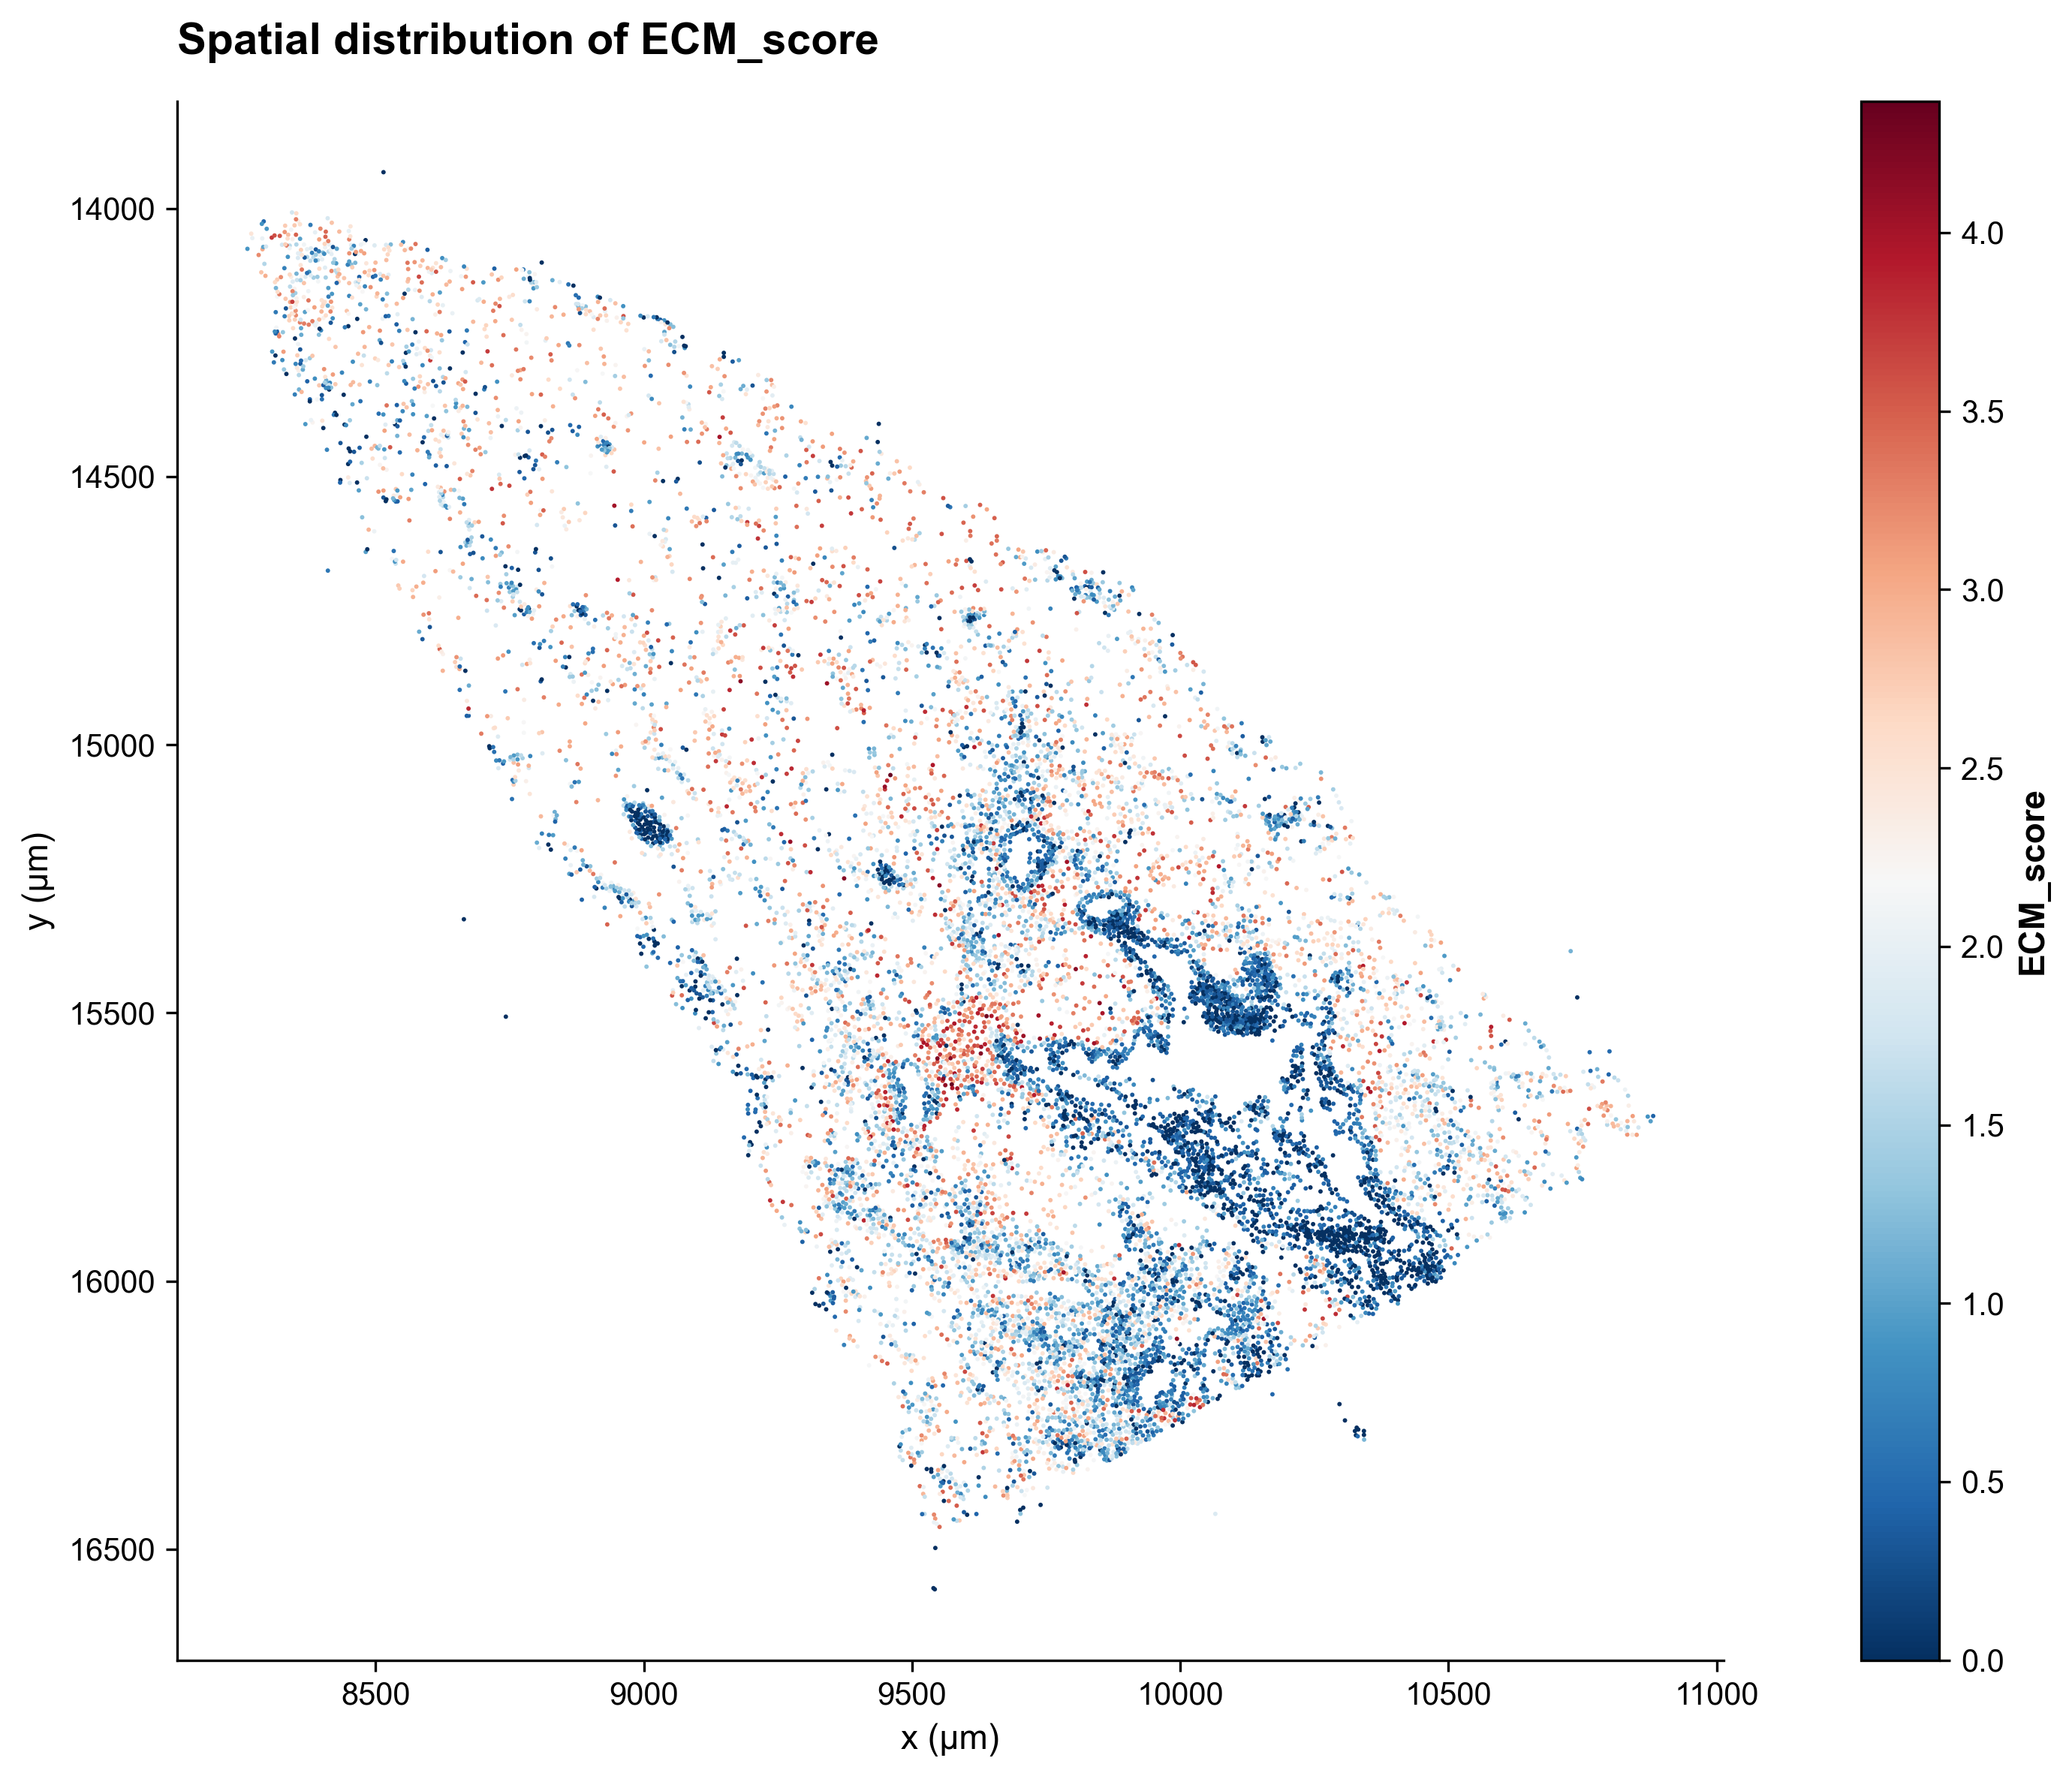

In [16]:
# -----------------------------------------------------------------------------
# 3. Normalize data and calculate gene signature score
# -----------------------------------------------------------------------------
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

ecm_genes_list = nichemap.preprocess.calculate_gene_signature_score(
    adata=adata,
    csv_path=gene_list,
    score_id=score_id,
    gene_column="Gene Symbol",
)

nichemap.plot.plot_spatial_score(
    adata,
    score_name=score_id,
    out_dir=out_dir,
)


[Grid] ECM_score
Shape: (300, 300), Non-empty: 10640
Figure saved to F:\spatial_data_lung\Xenium_Result_data\GSM8505449_result\ECM_score\Figure_1A_Raw_ECM_score_grid_map.png
Figure saved to F:\spatial_data_lung\Xenium_Result_data\GSM8505449_result\ECM_score\Figure_1B_Grid_cell_density.png


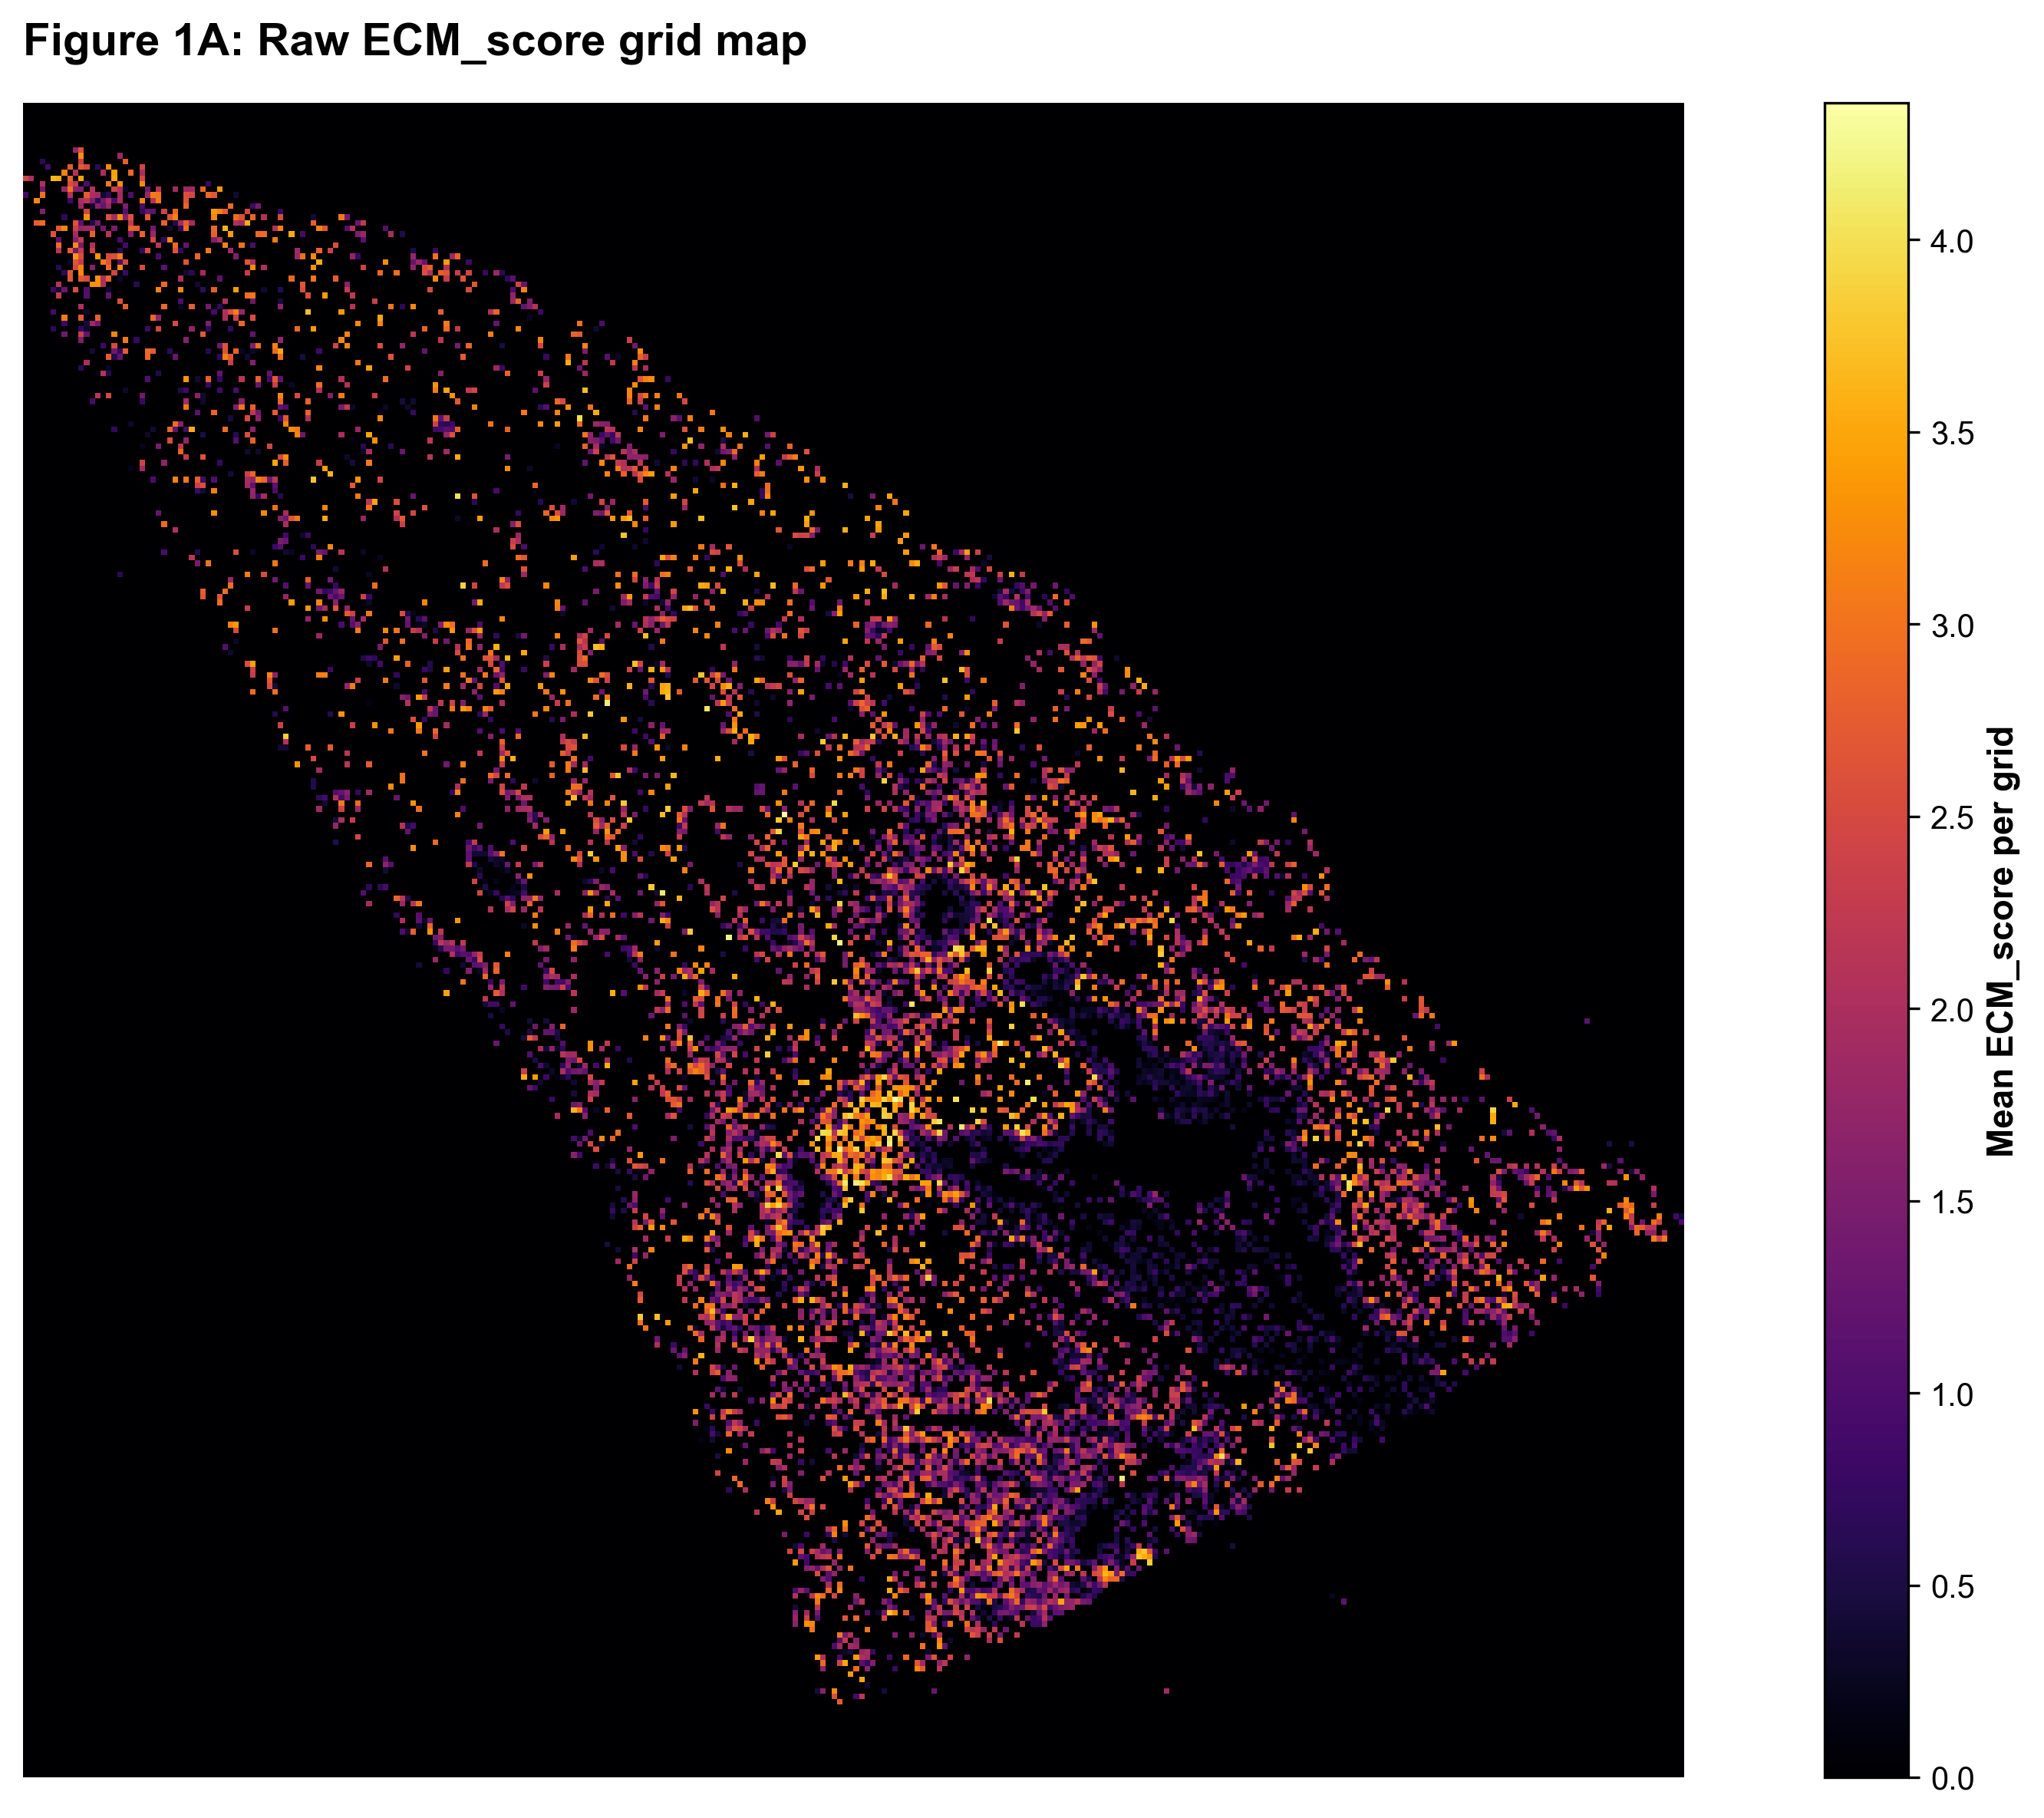

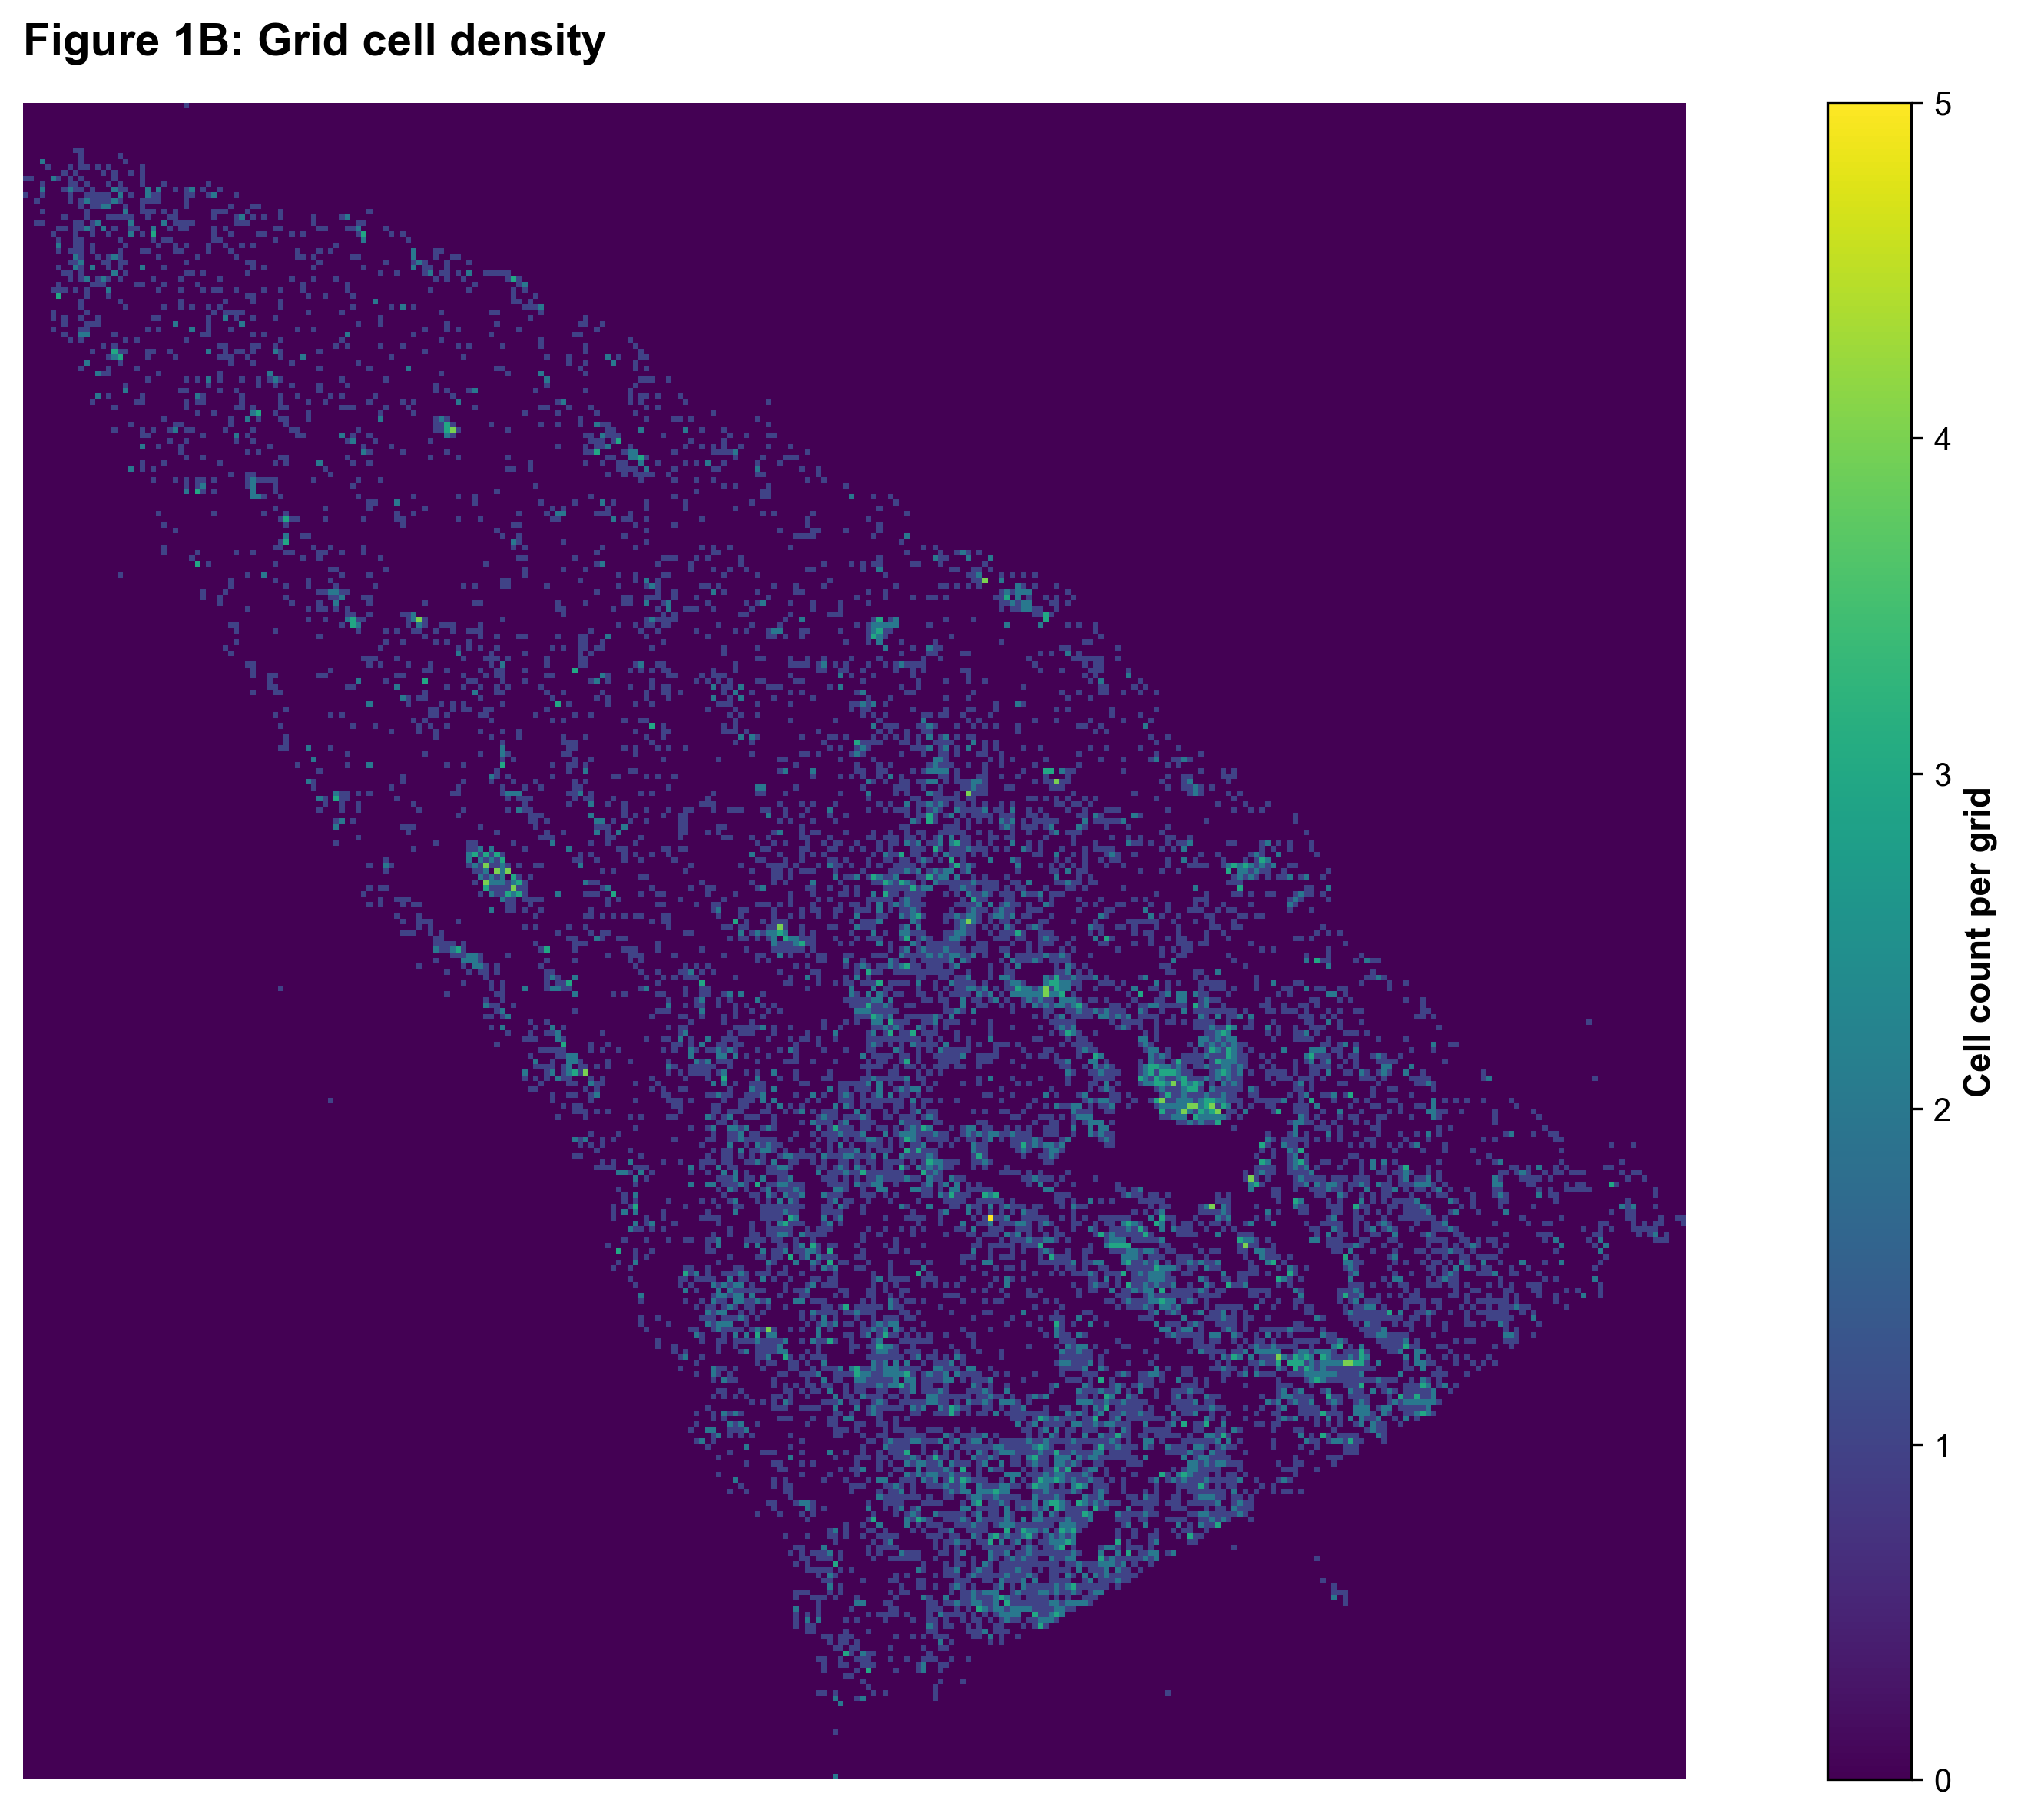

In [17]:
# -----------------------------------------------------------------------------
# 4. Build spatial grid and generate score maps
# -----------------------------------------------------------------------------
sigma_peak = 2

mean_map, smooth_map_peak, counts, xedges, yedges = nichemap.utils.generate_mean_grid_map(
    adata,
    score_id=score_id,
    bins=bins,
    sigma_peak=sigma_peak,
)

nichemap.plot.plot_grid_map(
    mean_map,
    xedges,
    yedges,
    cmap="inferno",
    title=f"Figure 1A: Raw {score_id} grid map",
    cbar_label=f"Mean {score_id} per grid",
    out_dir=out_dir,
)

nichemap.plot.plot_grid_map(
    counts,
    xedges,
    yedges,
    cmap="viridis",
    title="Figure 1B: Grid cell density",
    cbar_label="Cell count per grid",
    out_dir=out_dir,
)


Figure saved to F:\spatial_data_lung\Xenium_Result_data\GSM8505449_result\ECM_score\Figure_2A_Detected_niche_peaks.png
Figure saved to F:\spatial_data_lung\Xenium_Result_data\GSM8505449_result\ECM_score\Figure_2B_Peak_positions_on_spatial_map.png


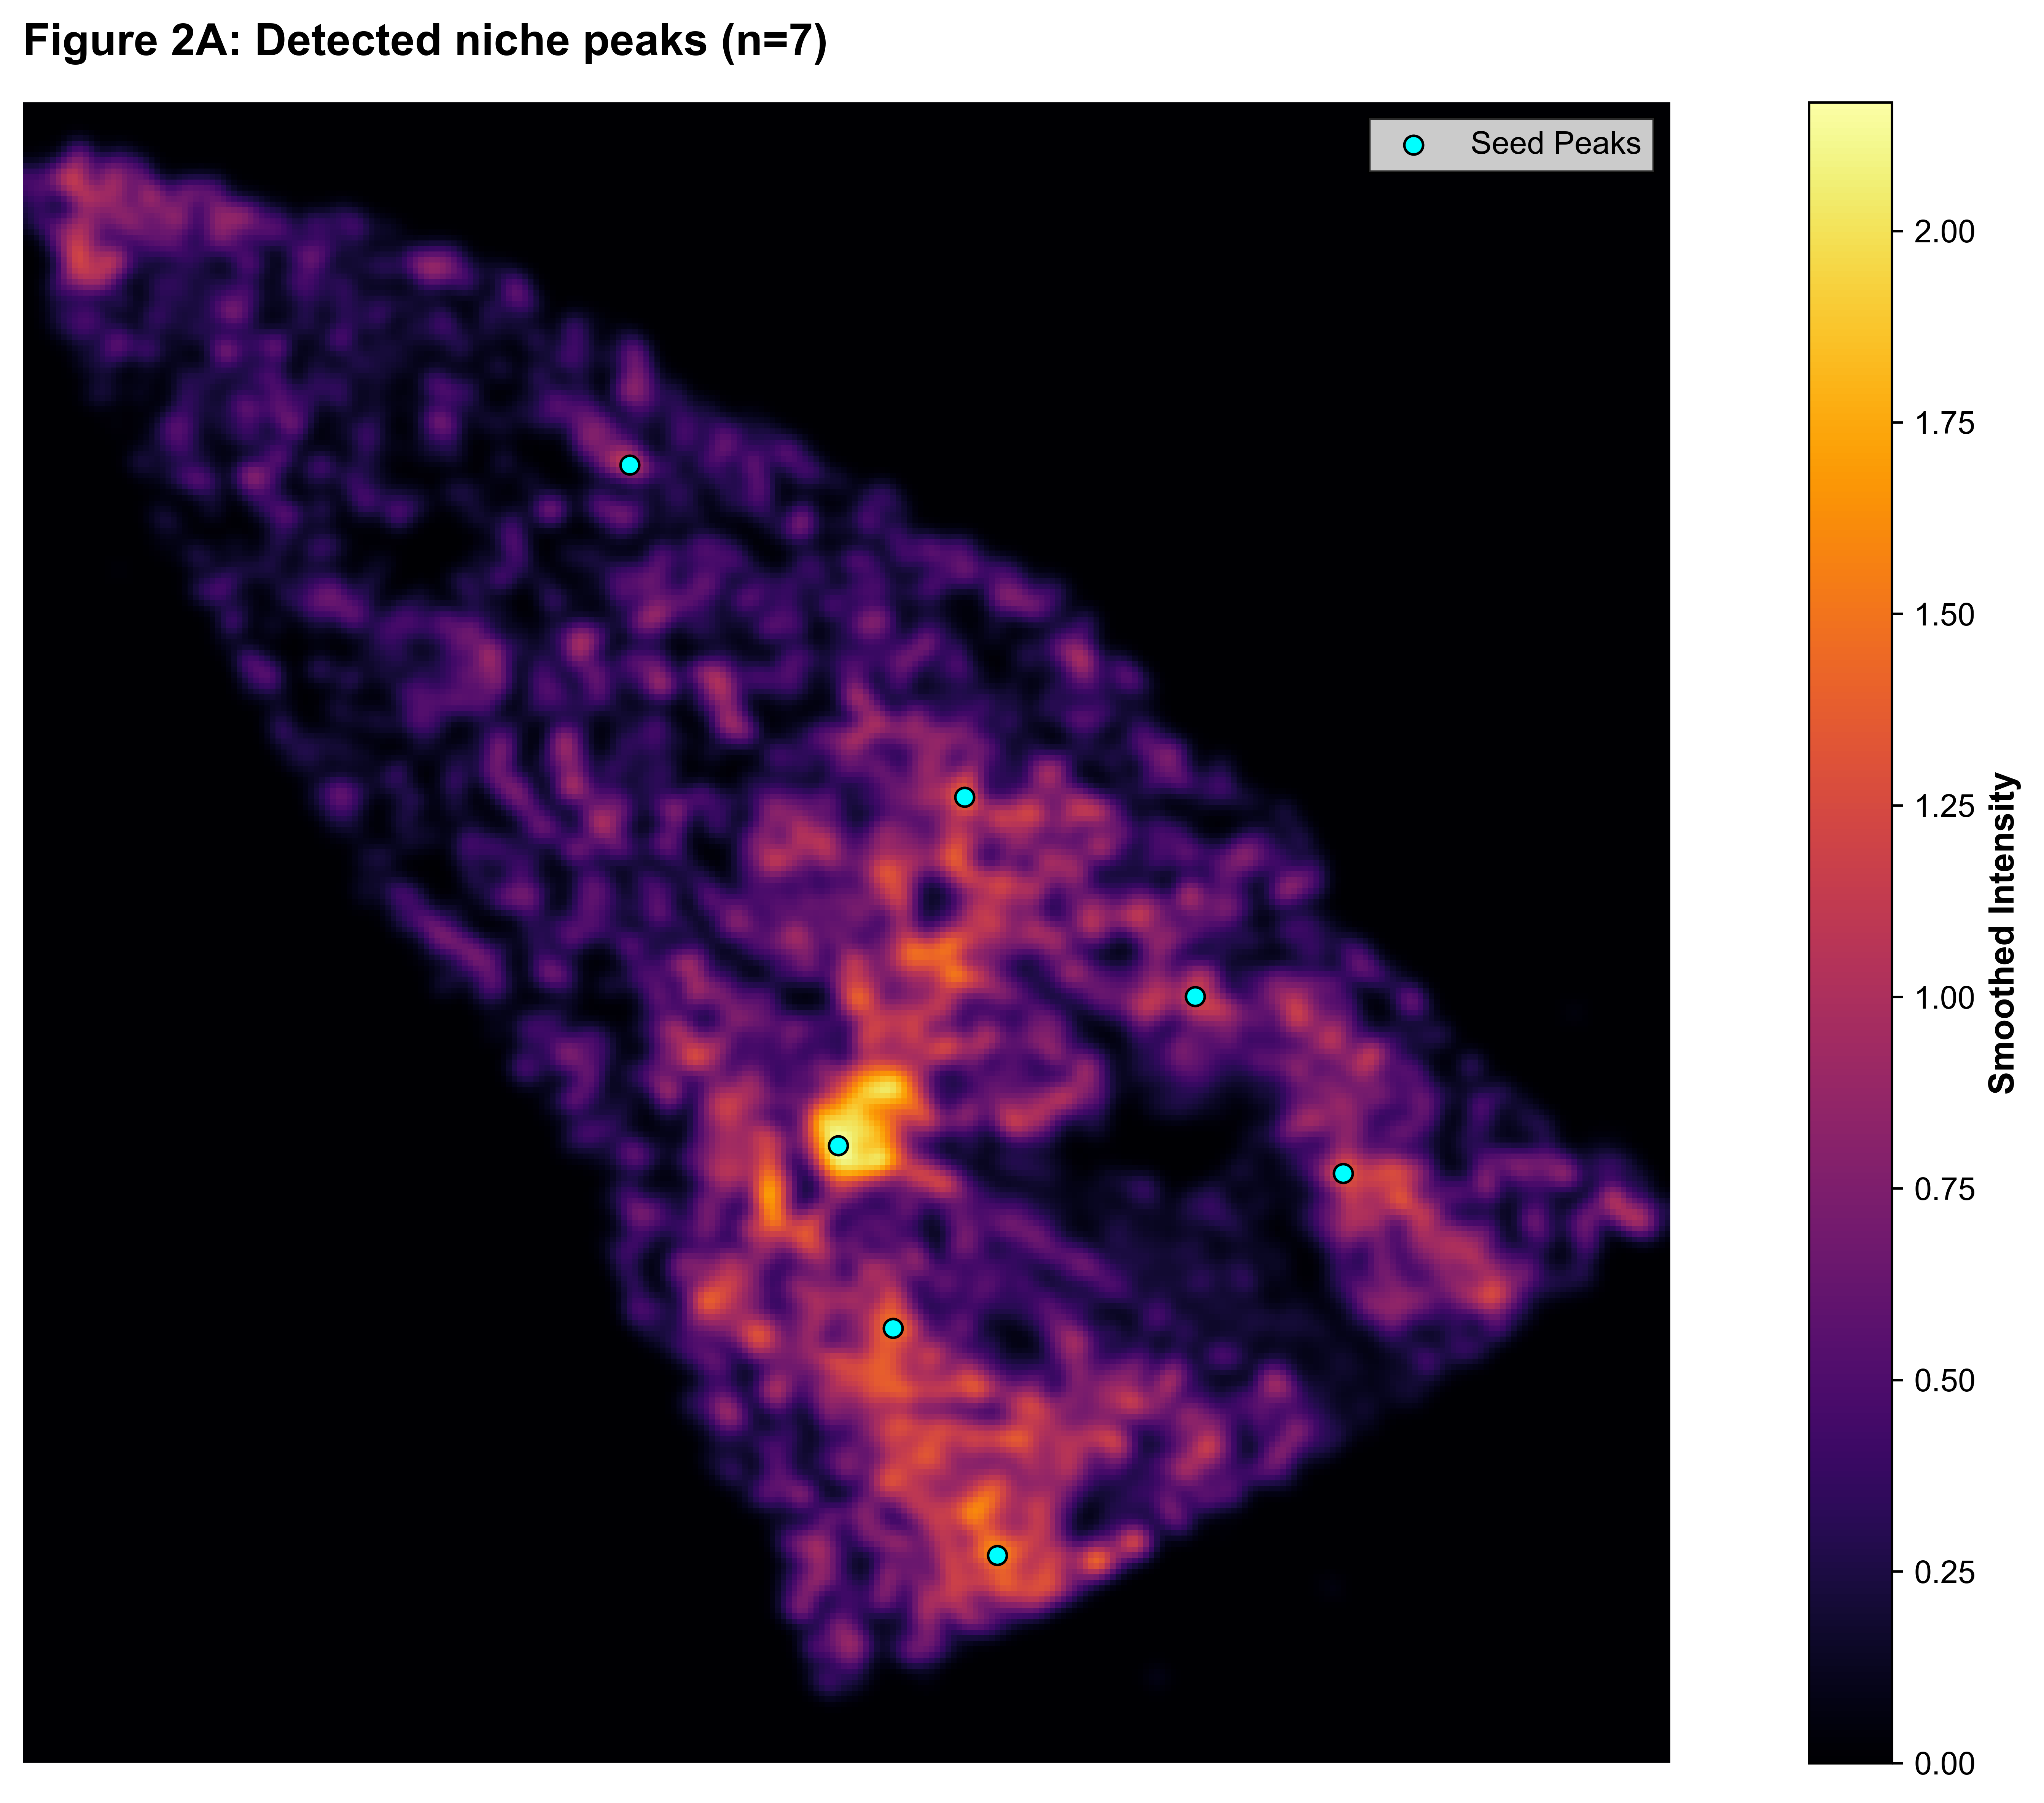

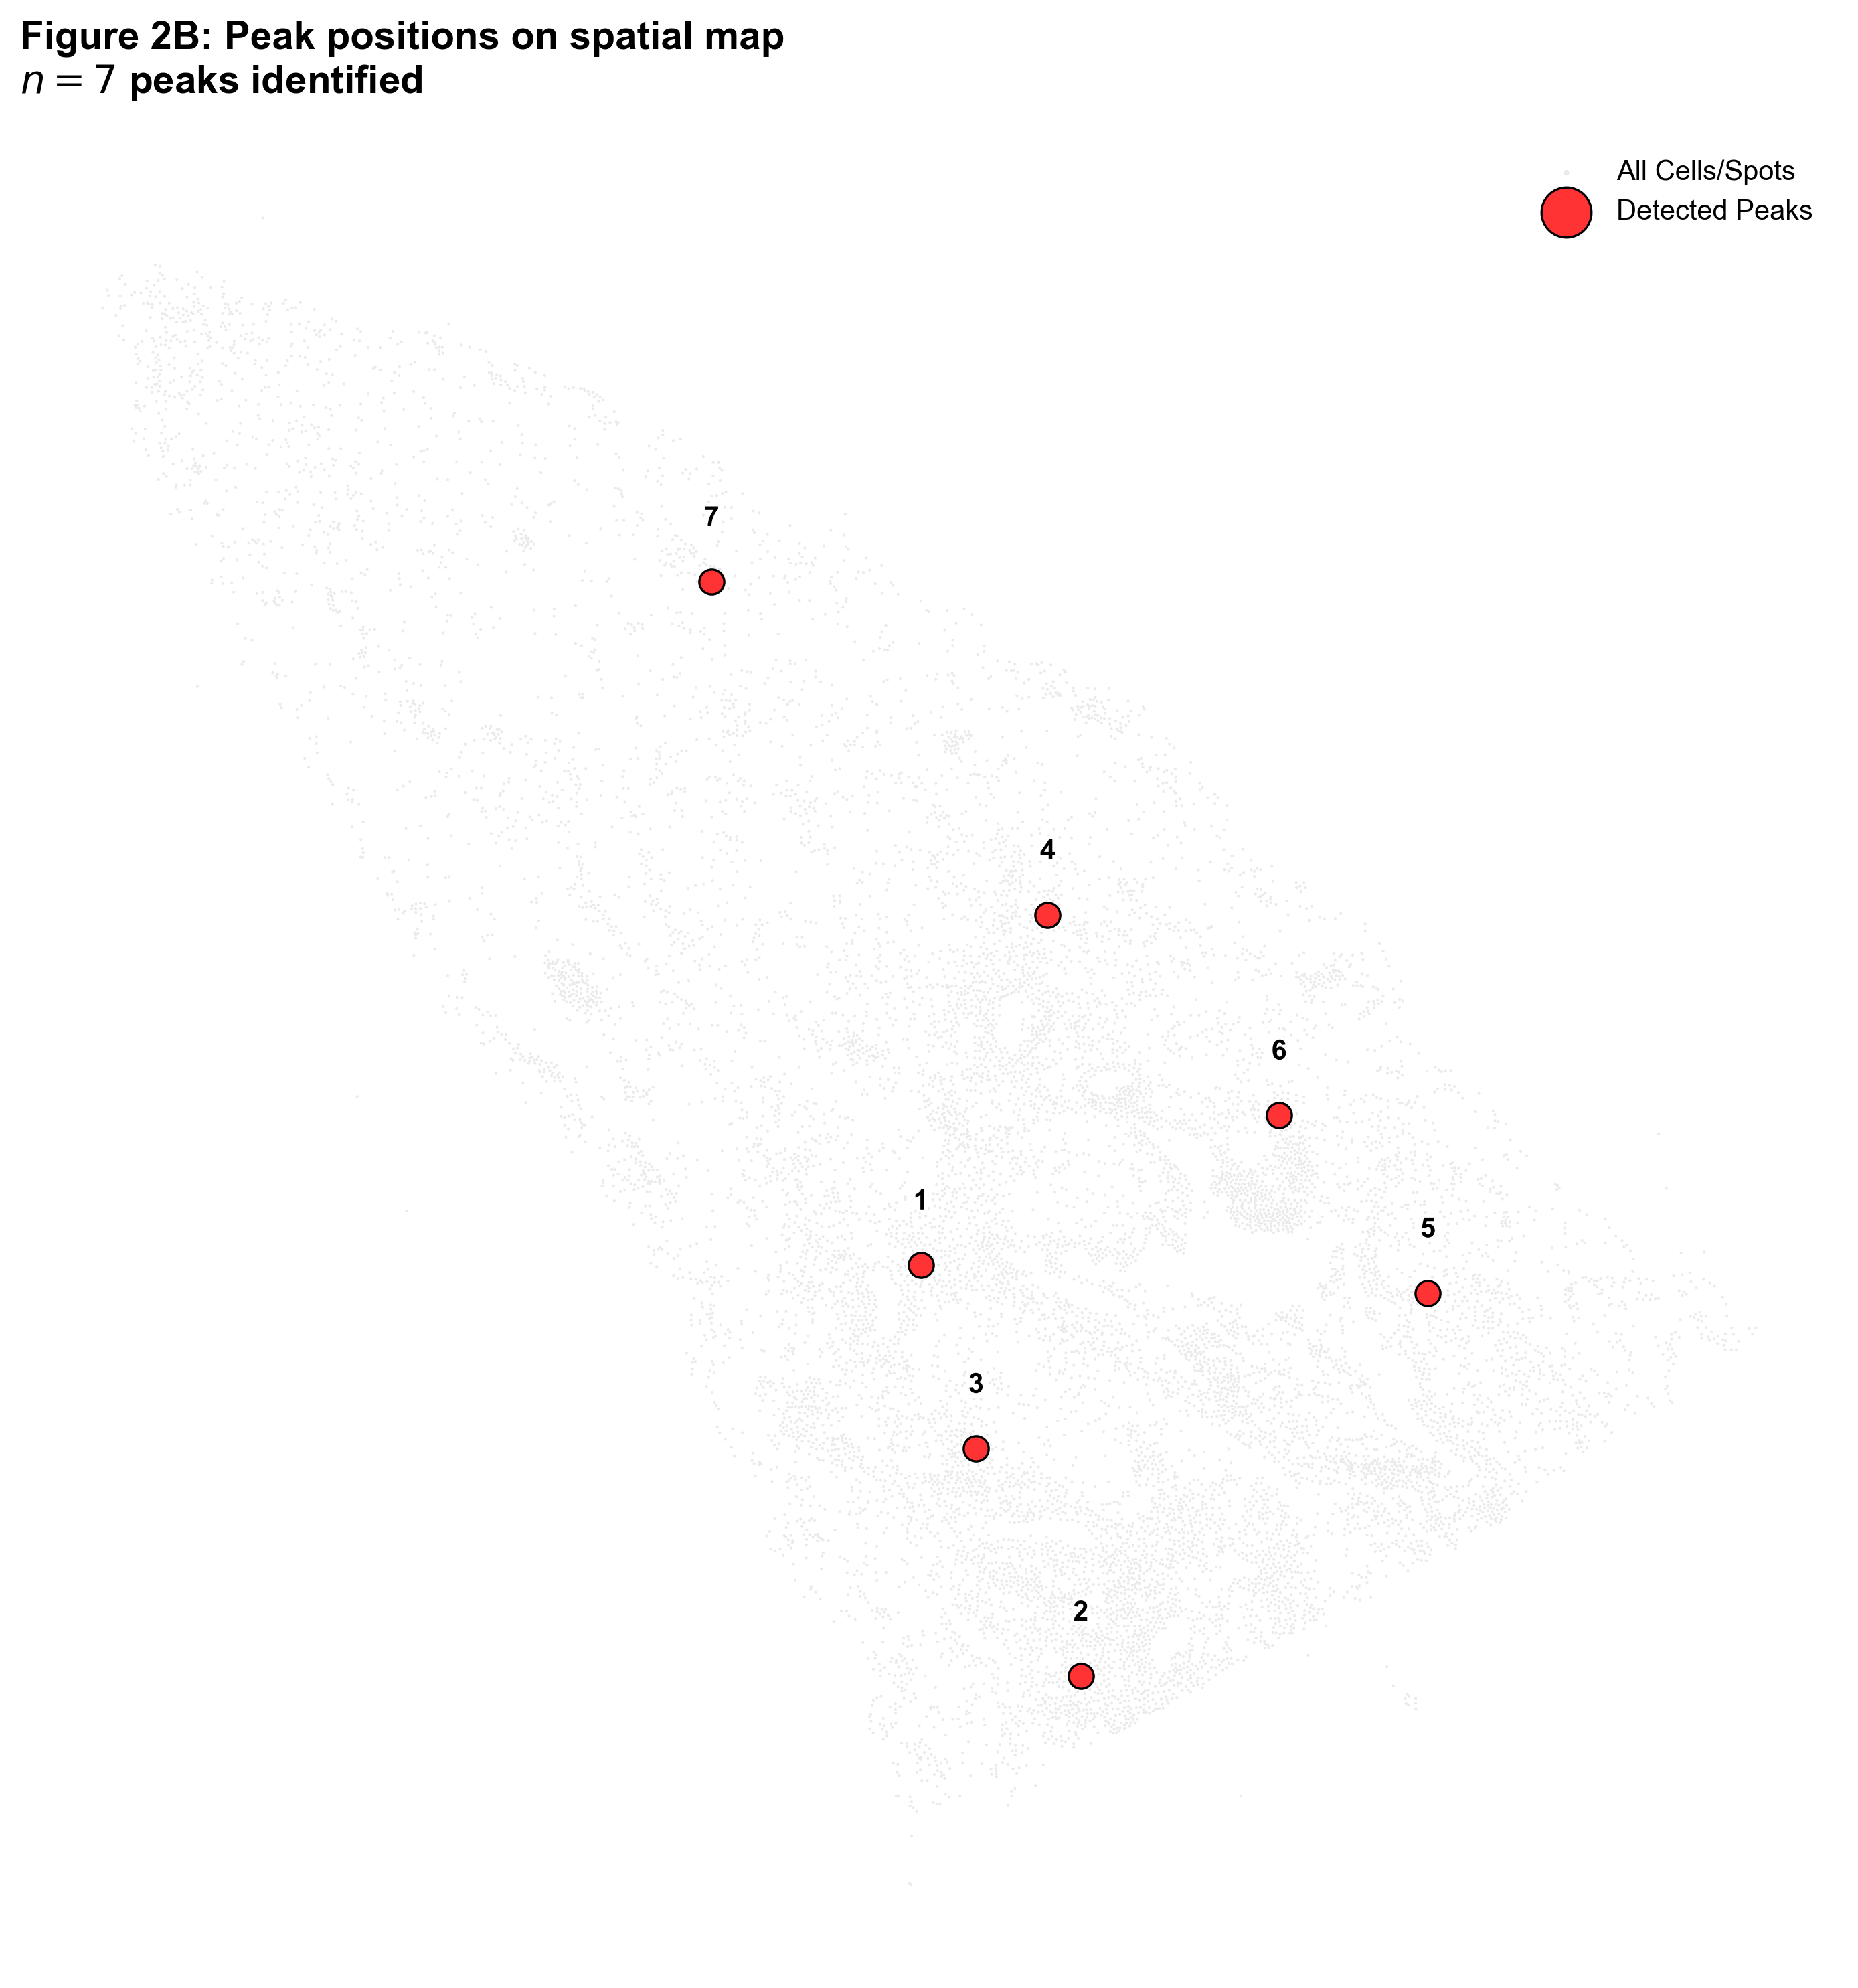

In [18]:
# -----------------------------------------------------------------------------
# 5. Detect niche seed peaks
# -----------------------------------------------------------------------------
_, _, peak_coords, results_df = nichemap.utils.find_peaks(
    smooth_map_peak,
    mode="heuristic",
    intensity_sigma=peak_intensity,
    use_otsu_base=True,
)

markers, peak_x, peak_y = nichemap.plot.visualize_and_export_peaks(
    smooth_map_peak,
    peak_coords,
    xedges,
    yedges,
    out_dir=out_dir,
)

x = adata.obs["x_centroid"].values
y = adata.obs["y_centroid"].values

peak_x, peak_y = nichemap.plot.plot_peak_positions_on_scatter(
    x_col=x,
    y_col=y,
    peak_coords=peak_coords,
    xedges=xedges,
    yedges=yedges,
    out_dir=out_dir,
)


Figure saved to F:\spatial_data_lung\Xenium_Result_data\GSM8505449_result\ECM_score\Figure_3A_Candidate_expansion_region.png
[Watershed] Niche count: 7
Figure saved to F:\spatial_data_lung\Xenium_Result_data\GSM8505449_result\ECM_score\Figure_4A_Spatial_Niche_Segmentation.png


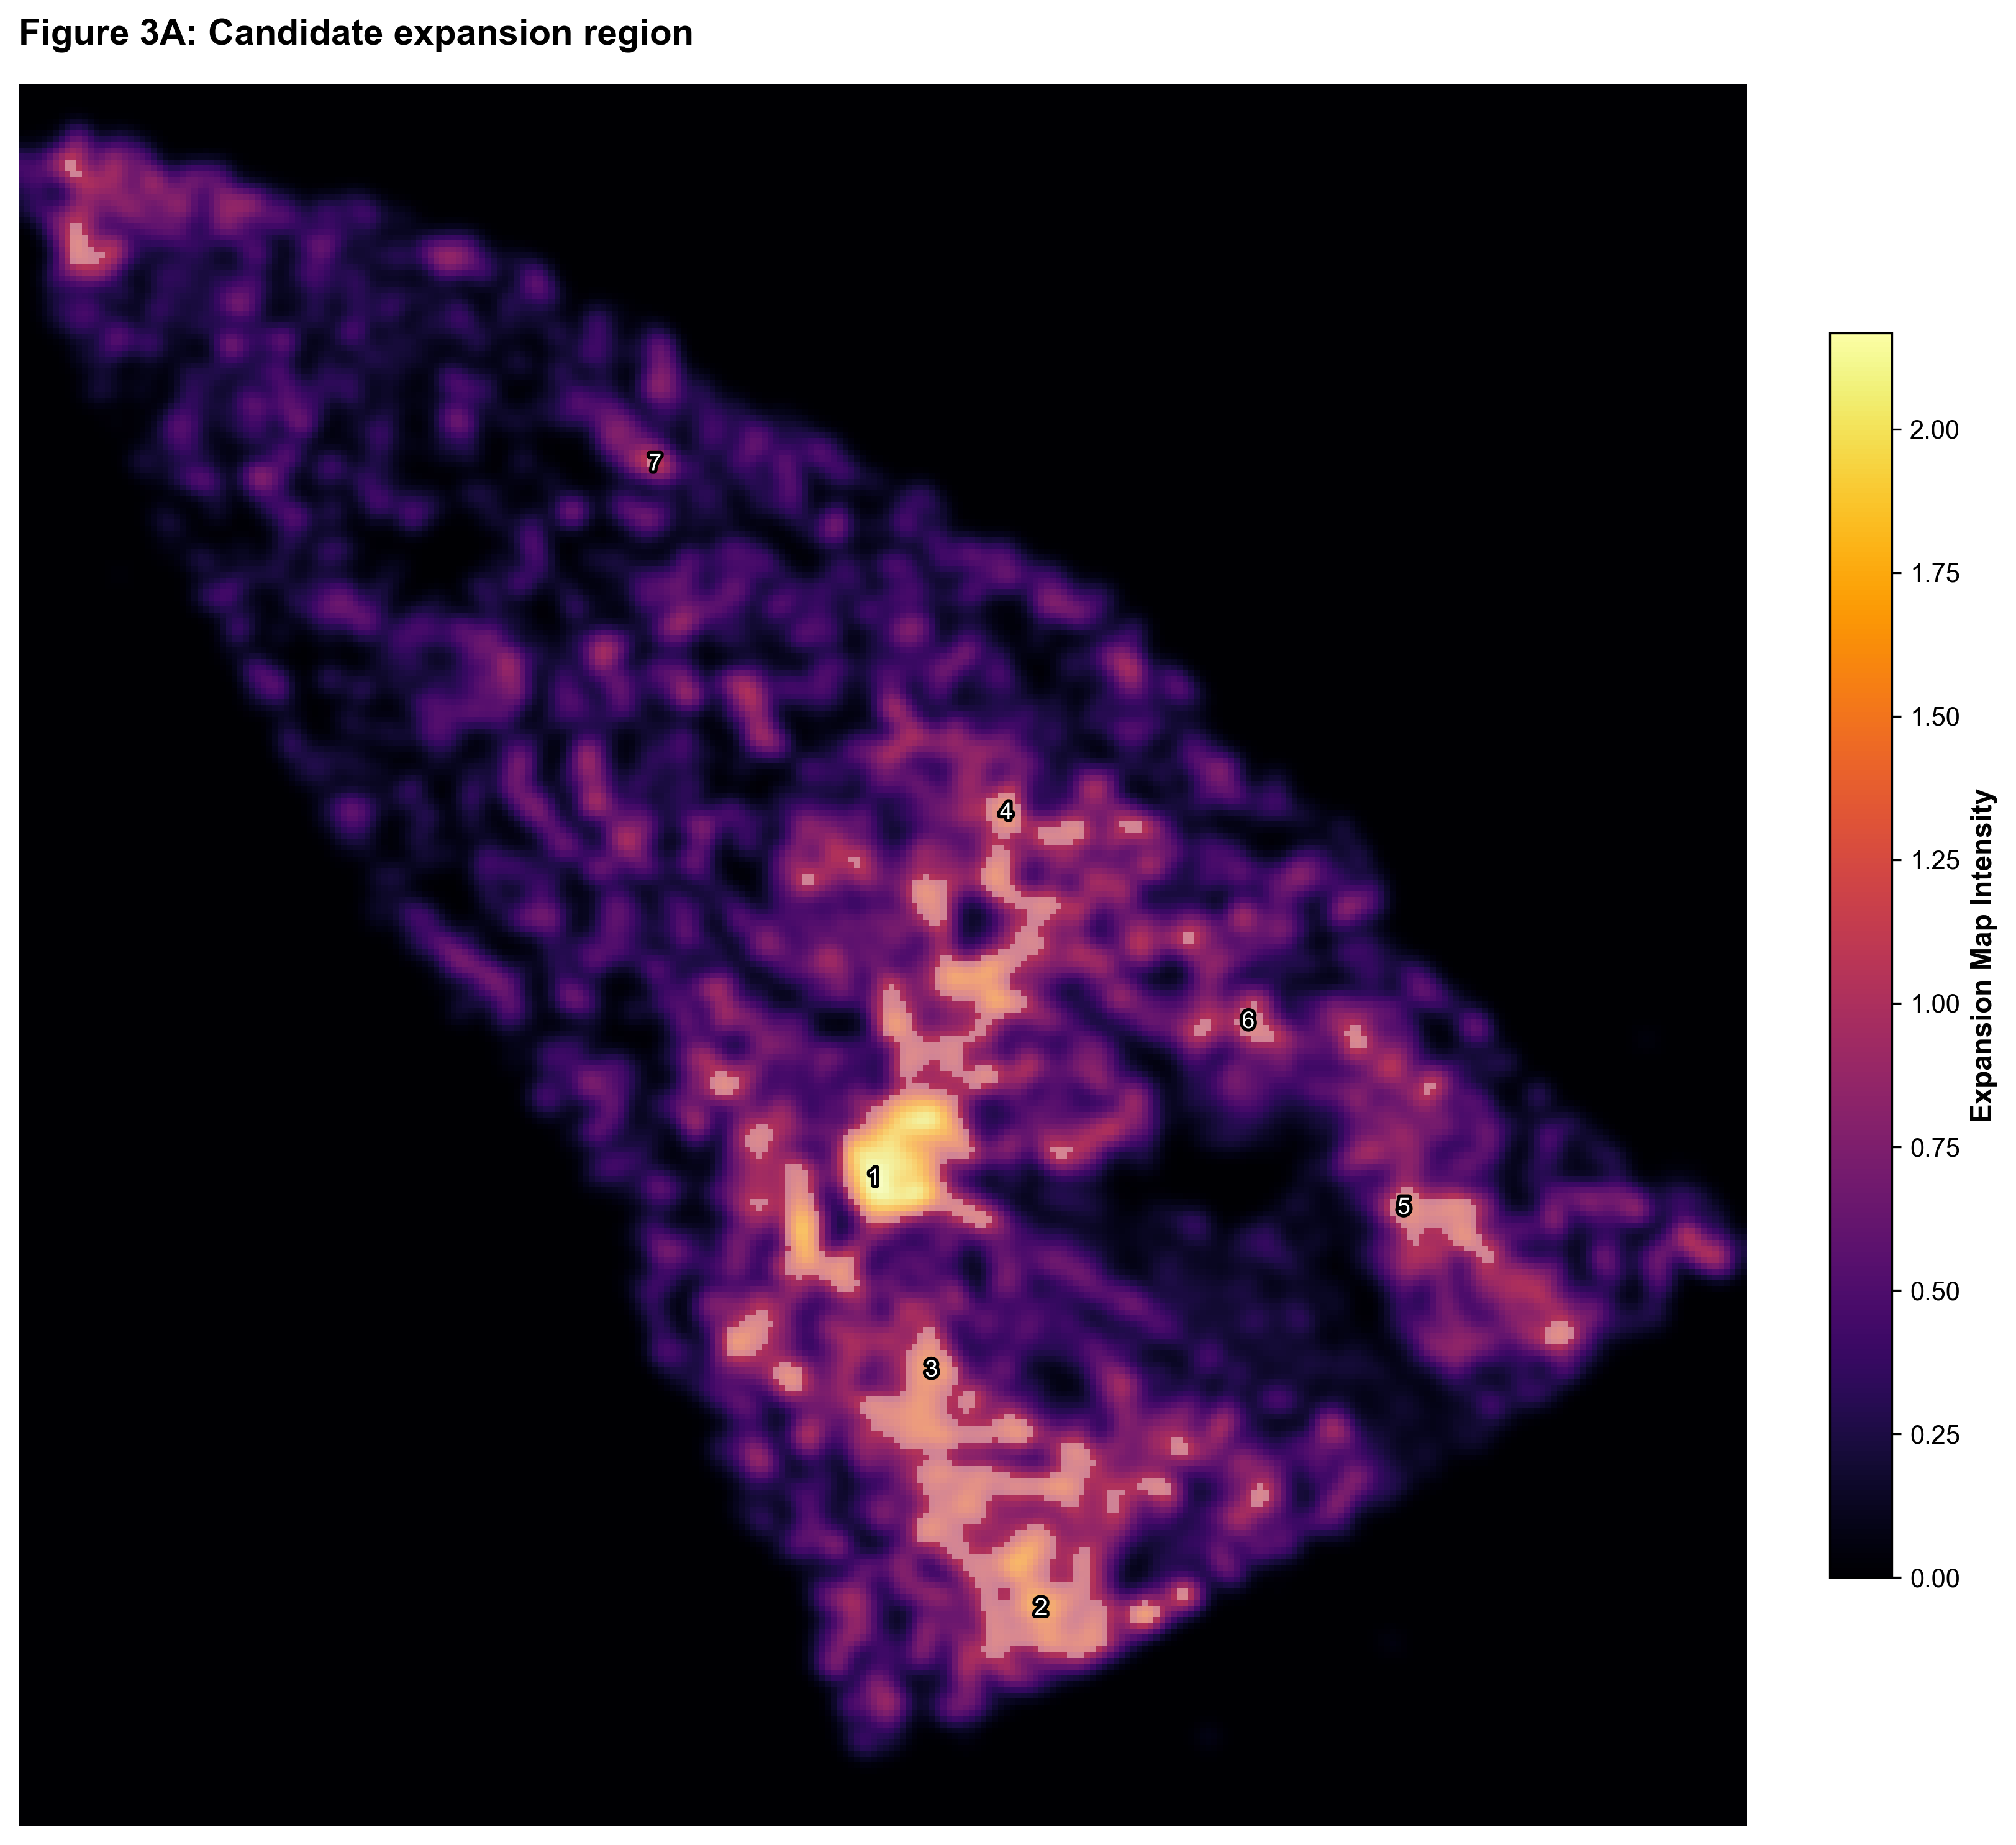

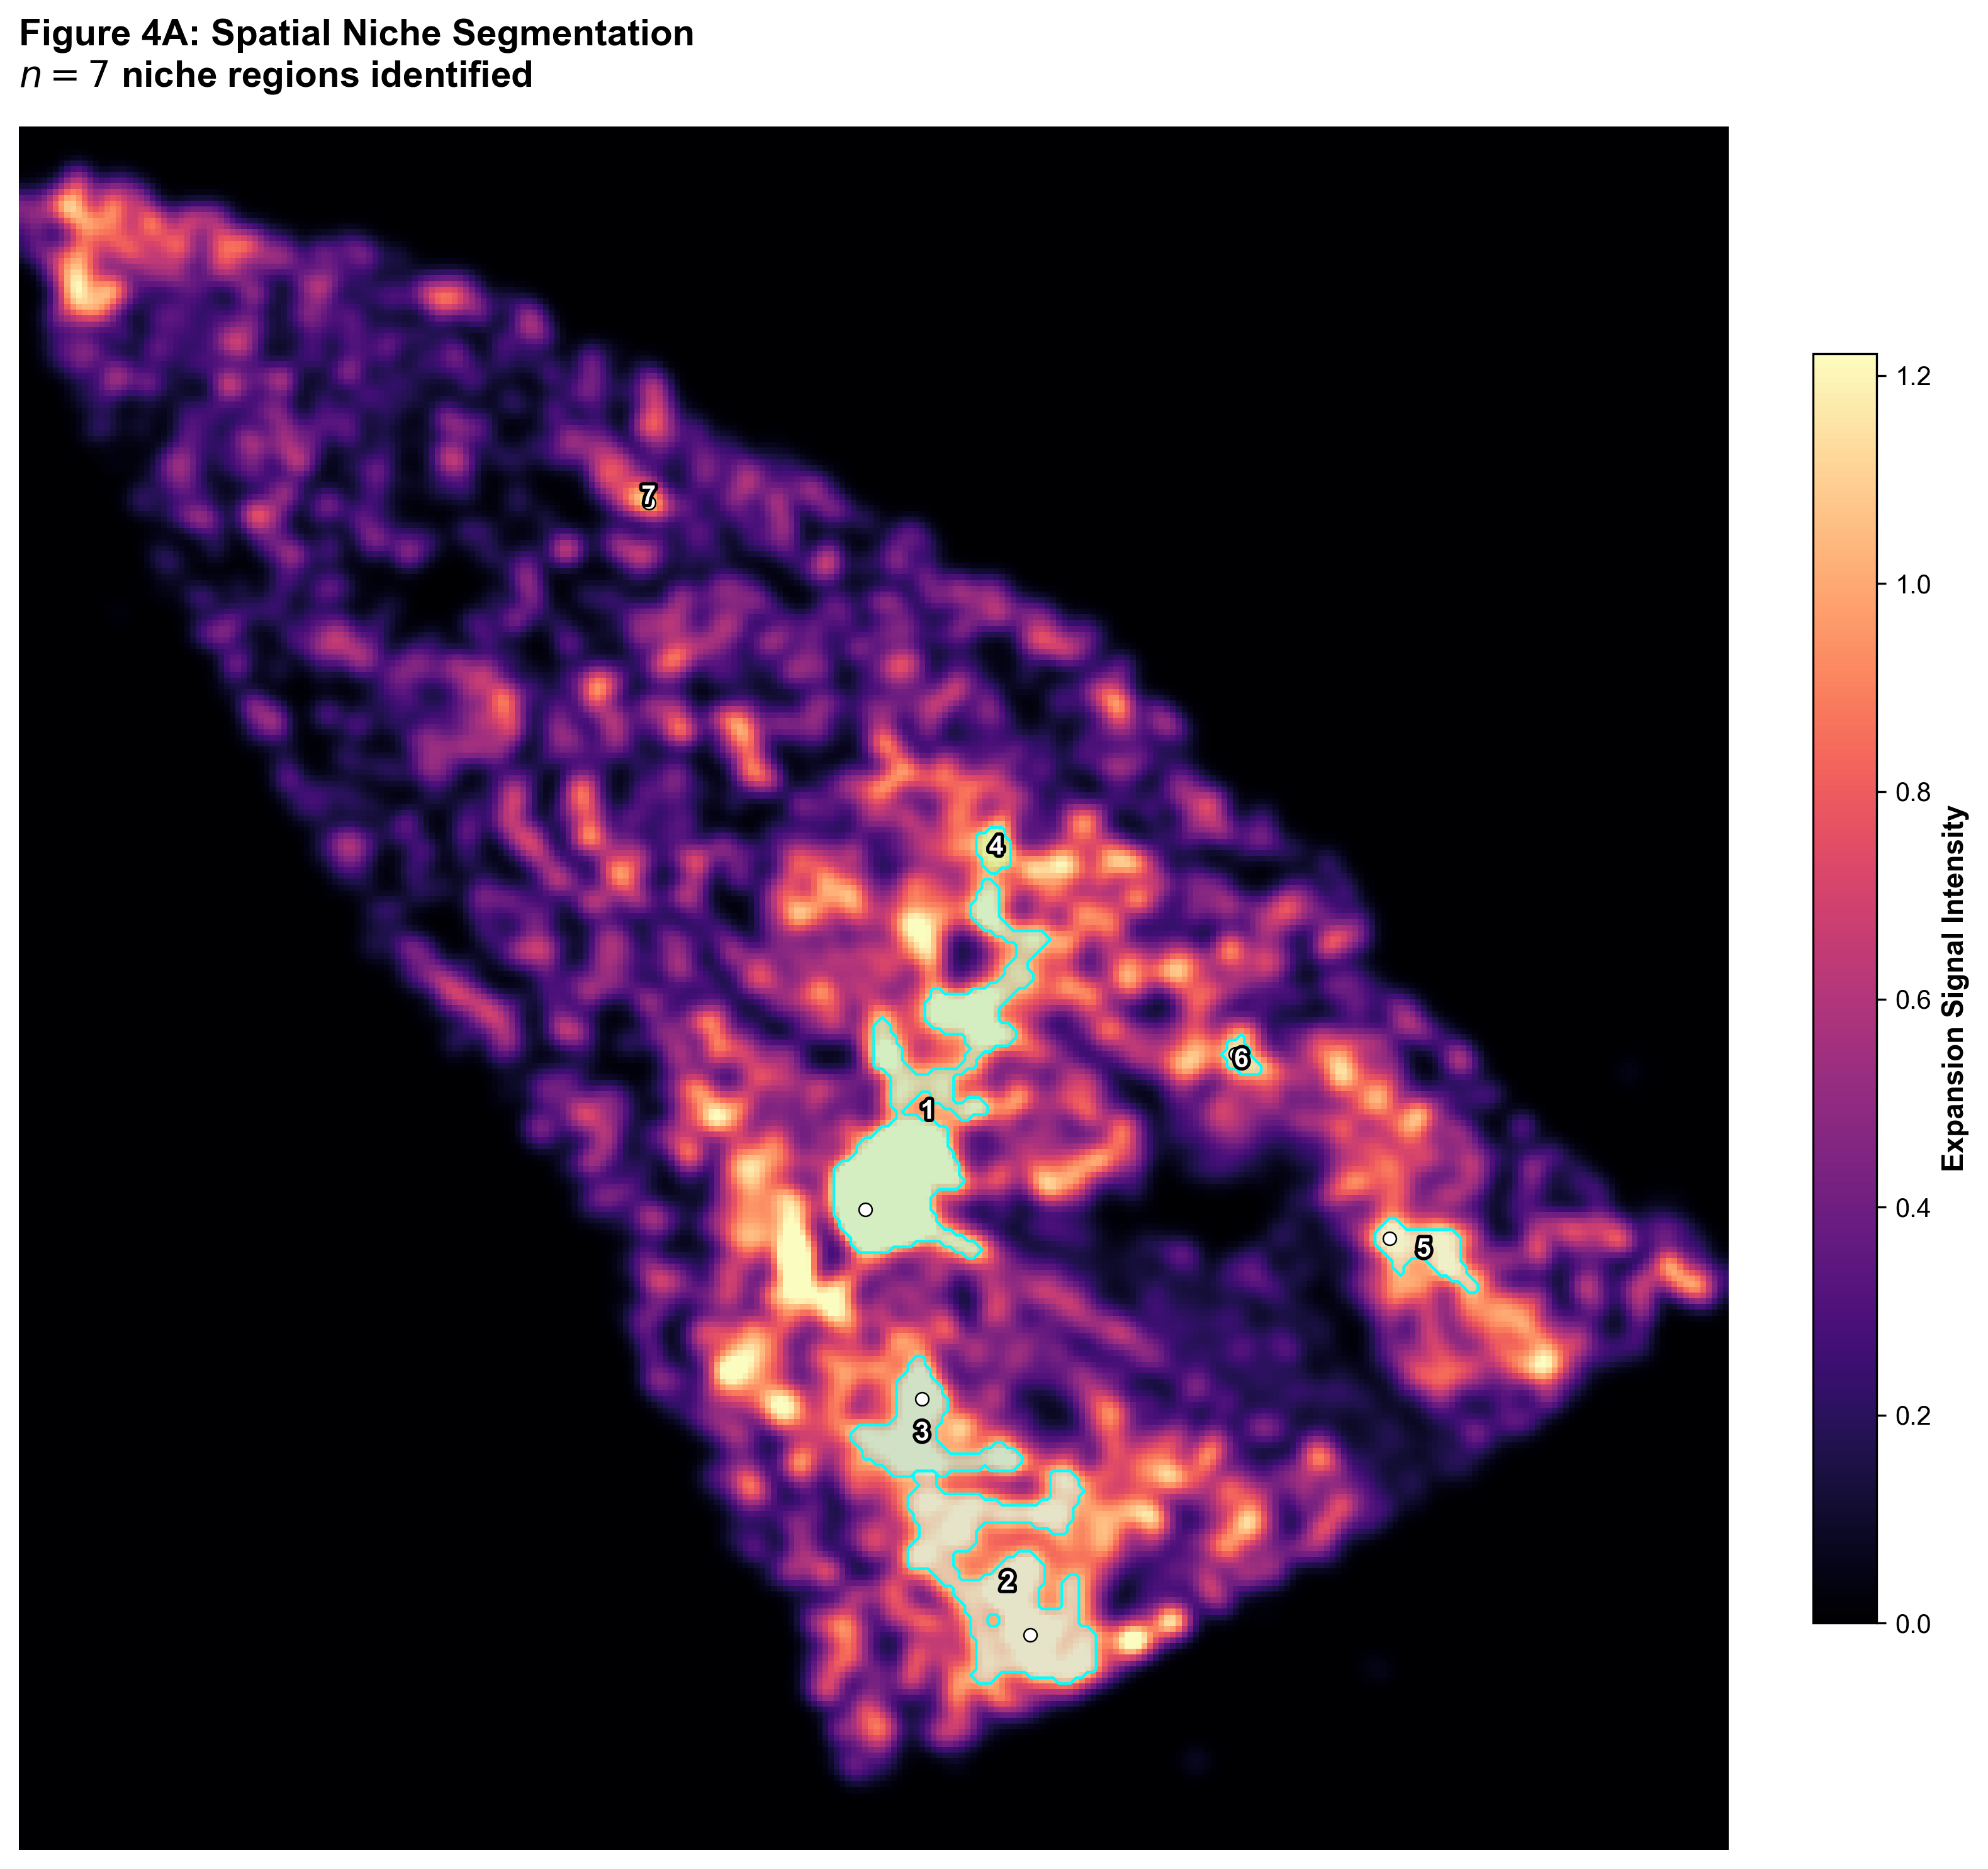

In [19]:
# -----------------------------------------------------------------------------
# 6. Create expansion mask and segment niche regions
# -----------------------------------------------------------------------------
smooth_map_exp, niche_mask = nichemap.utils.create_expansion_mask(
    mean_map,
    sigma=2,
    mode="heuristic",
    expansion_sigma=exp_intensity,
    use_otsu_base=True,
)

nichemap.plot.plot_expansion_mask(
    smooth_map_exp,
    niche_mask,
    peak_x,
    peak_y,
    xedges,
    yedges,
    out_dir=out_dir,
)

niche_labels, niche_ids = nichemap.utils.segment_niche_regions(
    smooth_map_exp,
    markers,
    niche_mask,
)

nichemap.plot.plot_niche_map(
    smooth_map_exp,
    niche_labels,
    peak_x,
    peak_y,
    xedges,
    yedges,
    cmap_base="magma",
    cmap_labels="Set3",
    out_dir=out_dir,
)


[Assign] ECM_score_niche_id
ECM_score_niche_id
0    11632
1      648
2      619
3      252
5       77
Name: count, dtype: int64
Computing vector boundaries for niche sketching...
Computing niche centroids for in situ labeling...
Figure saved to F:\spatial_data_lung\Xenium_Result_data\GSM8505449_result\ECM_score\Figure_4B_Cell-level_niche_assignment.png


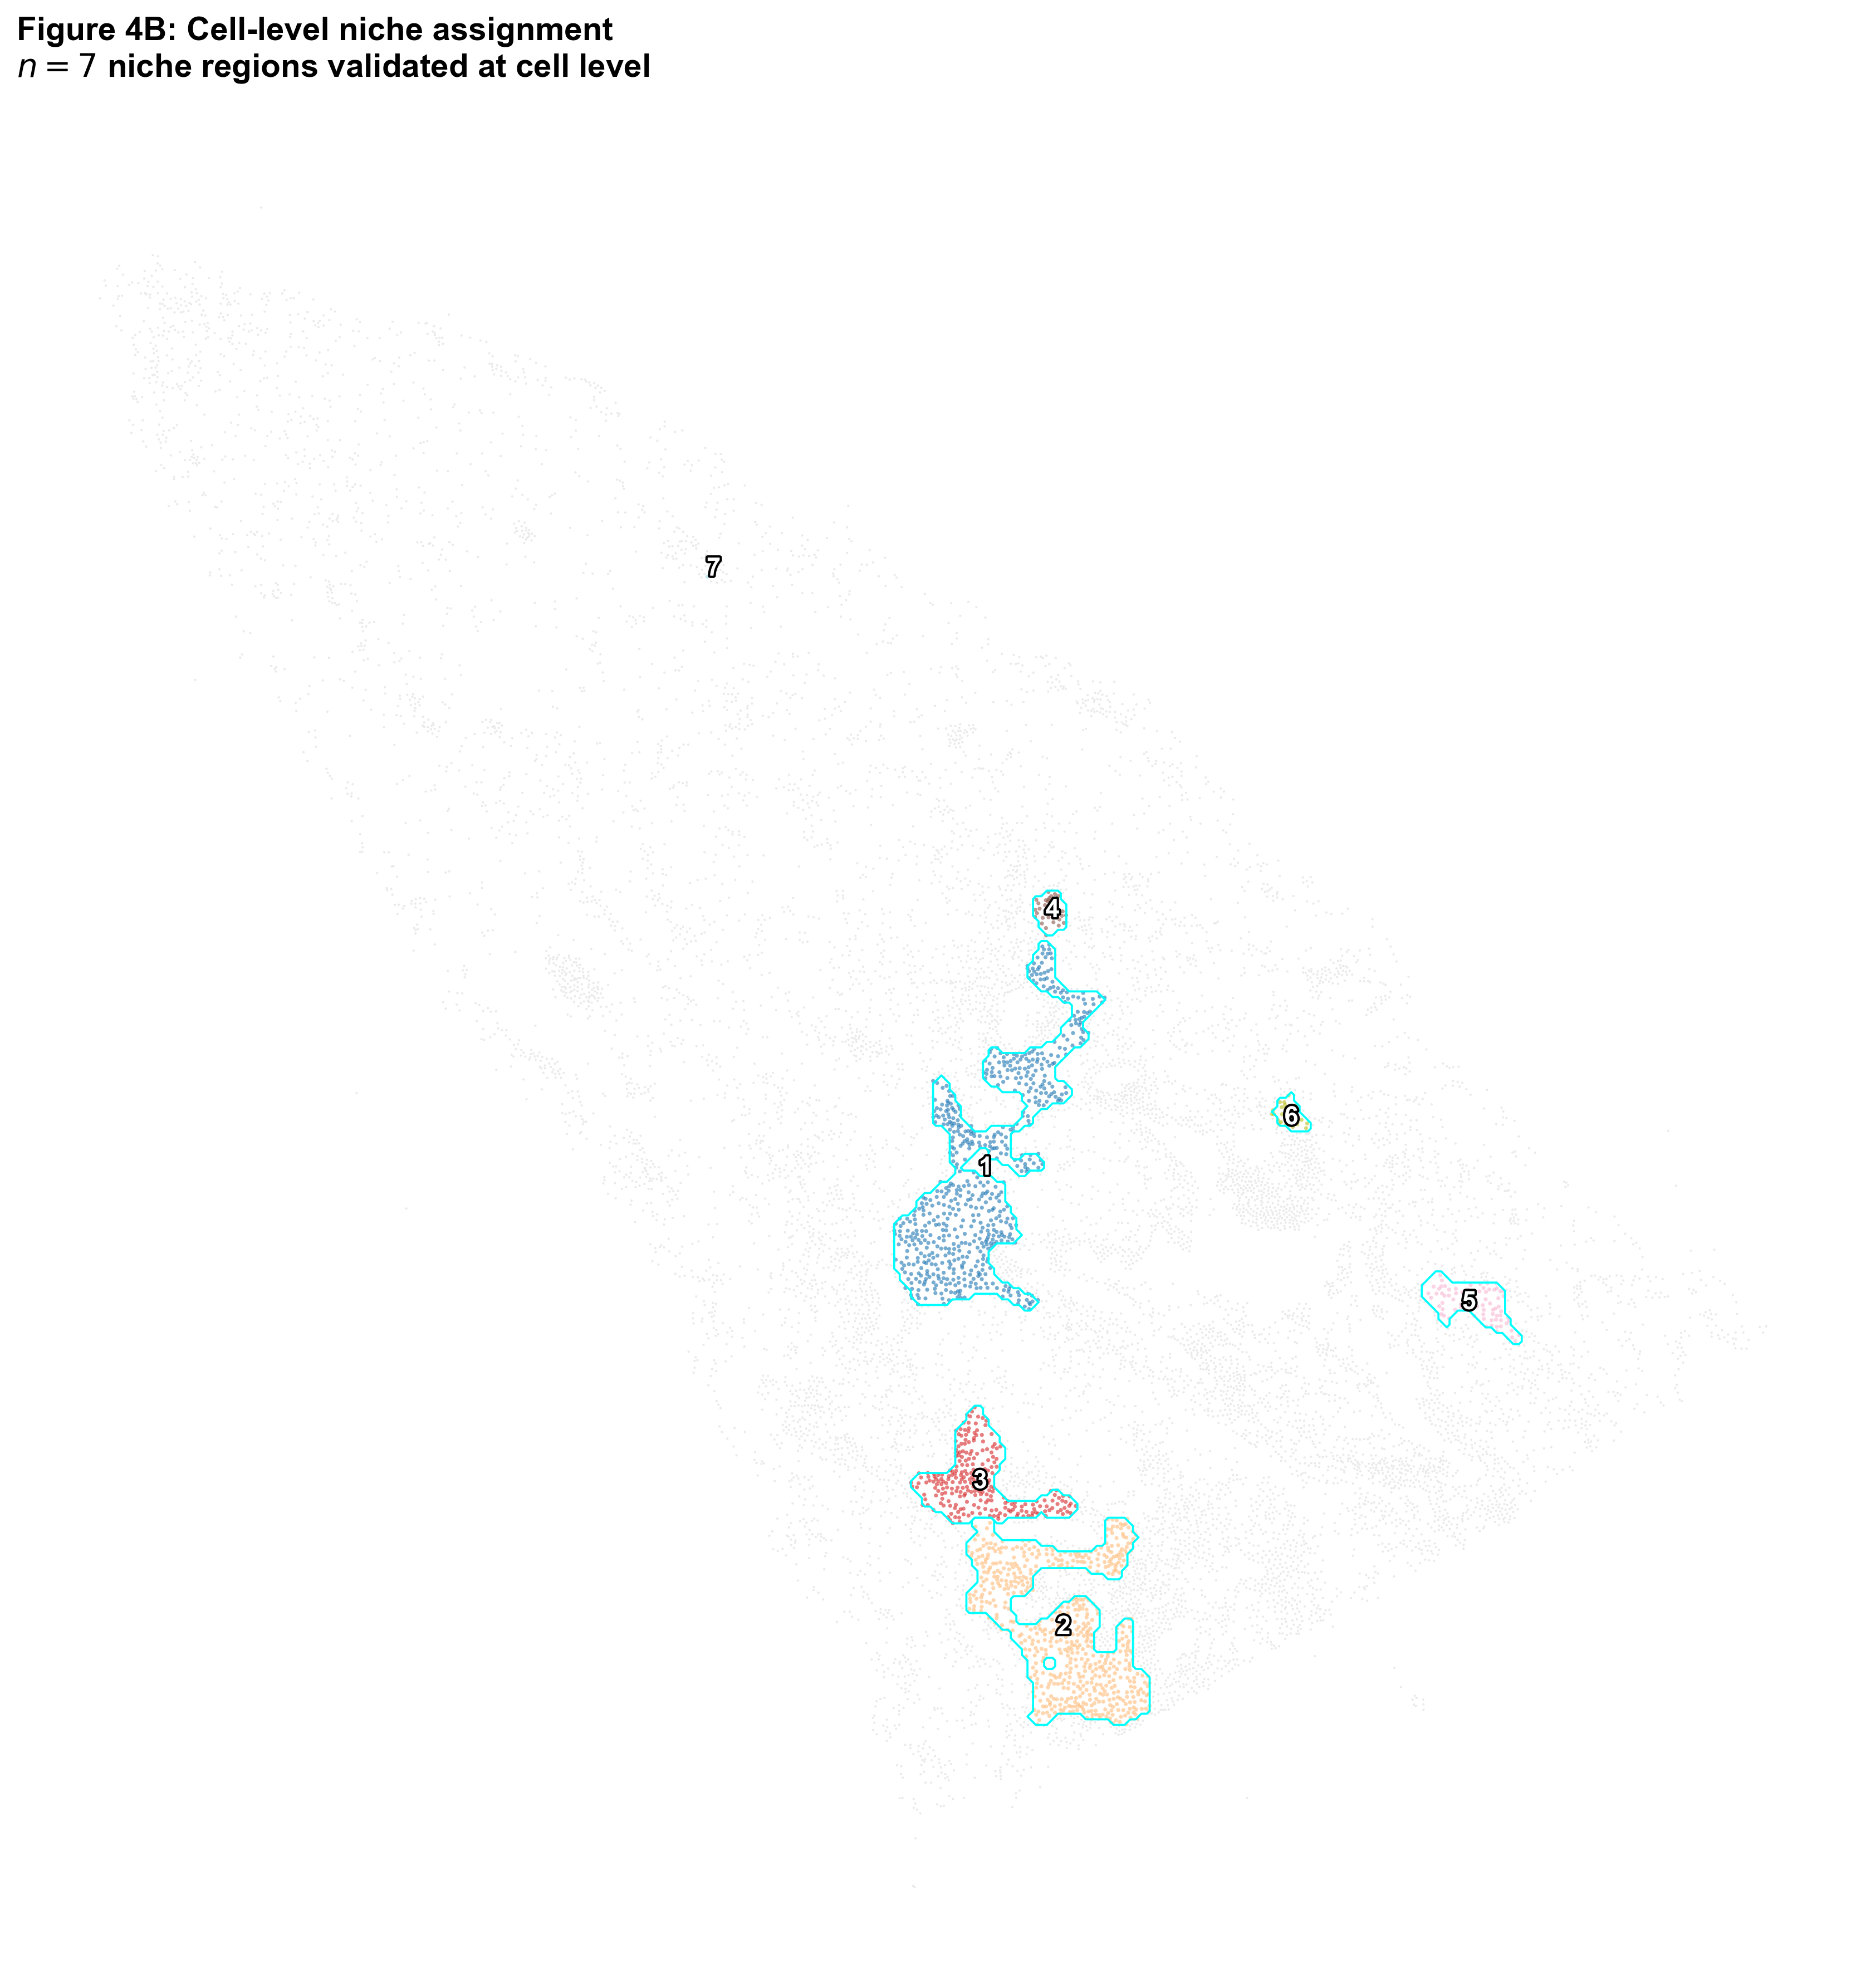

In [20]:
# -----------------------------------------------------------------------------
# 7. Map niche labels back to cells
# -----------------------------------------------------------------------------
nichemap.utils.map_niche_to_cells(
    adata,
    niche_labels,
    xedges,
    yedges,
    x_col="x_centroid",
    y_col="y_centroid",
    output_col=f"{score_id}_niche_id",
    verbose=True,
)

nichemap.plot.plot_cell_level_niches(
    adata,
    niche_labels,
    xedges,
    yedges,
    niche_column=f"{score_id}_niche_id",
    coords_columns=("x_centroid", "y_centroid"),
    s_bg=1,
    s_fg=3,
    cmap="tab20",
    boundary_color="cyan",
    out_dir=out_dir,
    verbose=True,
)


In [21]:
# -----------------------------------------------------------------------------
# 8. Export results
# -----------------------------------------------------------------------------
nichemap.utils.export_niche_results(
    adata=adata,
    out_dir=out_dir,
    niche_column=f"{score_id}_niche_id",
    file_prefix="GSM8505449",
    export_csv=True,
    export_h5ad=True,
)


[Export] Assigned: 1658/13290


## Optional: directly specify the transcript table

If a folder contains more than one `*_transcripts.csv.gz` file, specify the file explicitly with `load_xenium_transcript_data`.

In [22]:
# Optional usage only when multiple transcript tables are present.
# adata = nichemap.preprocess.load_xenium_transcript_data(
#     base_dir=base_dir,
#     transcript_file=r"F:\spatial_data_lung\IPF_2\GSM8505449\GSM8505449_TILD049MA_transcripts.csv.gz",
#     anno_file=None,
#     verbose=True,
# )
